In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from sklearn.ensemble import RandomForestClassifier


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Students Social Media Addiction.csv  


In [ ]:


df = pd.read_csv("Students Social Media Addiction.csv")
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [ ]:
df.shape

(705, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [ ]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [ ]:
def addiction_level(score):
  if score <= 3:
    return "Low Addiction"
  elif score <= 6:
    return "Medium Addiction"
  else:
    return "High Addiction"

df["Addiction_Level"] = df["Addicted_Score"].apply(addiction_level)


In [ ]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Addiction_Level
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High Addiction
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Low Addiction
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High Addiction
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Medium Addiction
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,High Addiction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5,Medium Addiction
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9,High Addiction
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7,High Addiction
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4,Medium Addiction


In [ ]:
df["Addicted"] = df["Addiction_Level"].apply(lambda x:1 if x in ["Medium Addiction", "High Addiction"] else 0)

In [ ]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Addiction_Level,Addicted
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High Addiction,1
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Low Addiction,0
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High Addiction,1
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Medium Addiction,1
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,High Addiction,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5,Medium Addiction,1
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9,High Addiction,1
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7,High Addiction,1
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4,Medium Addiction,1


In [ ]:
df['Addicted'] = df['Addiction_Level'].apply(lambda x:1 if x in ['Medium Addiction', 'High Addiction'] else 0)

In [ ]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Addiction_Level,Addicted
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High Addiction,1
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Low Addiction,0
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High Addiction,1
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Medium Addiction,1
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,High Addiction,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5,Medium Addiction,1
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9,High Addiction,1
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7,High Addiction,1
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4,Medium Addiction,1


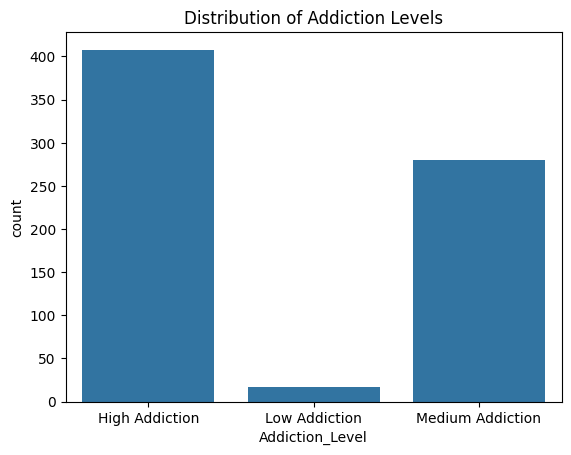

In [ ]:
sns.countplot(x="Addiction_Level", data=df)
plt.title("Distribution of Addiction Levels")
plt.show()

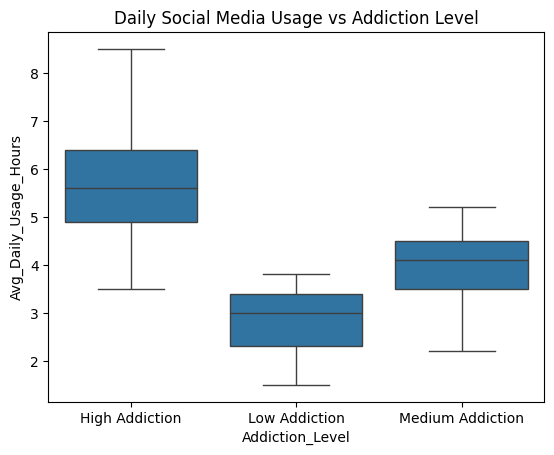

In [ ]:
sns.boxplot(x="Addiction_Level", y="Avg_Daily_Usage_Hours", data=df)
plt.title("Daily Social Media Usage vs Addiction Level")
plt.show()

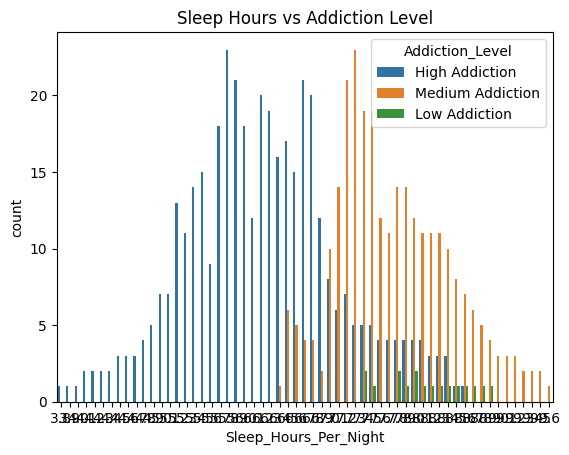

In [ ]:
sns.countplot(x='Sleep_Hours_Per_Night', hue='Addiction_Level', data=df)
plt.title('Sleep Hours vs Addiction Level')
plt.show()

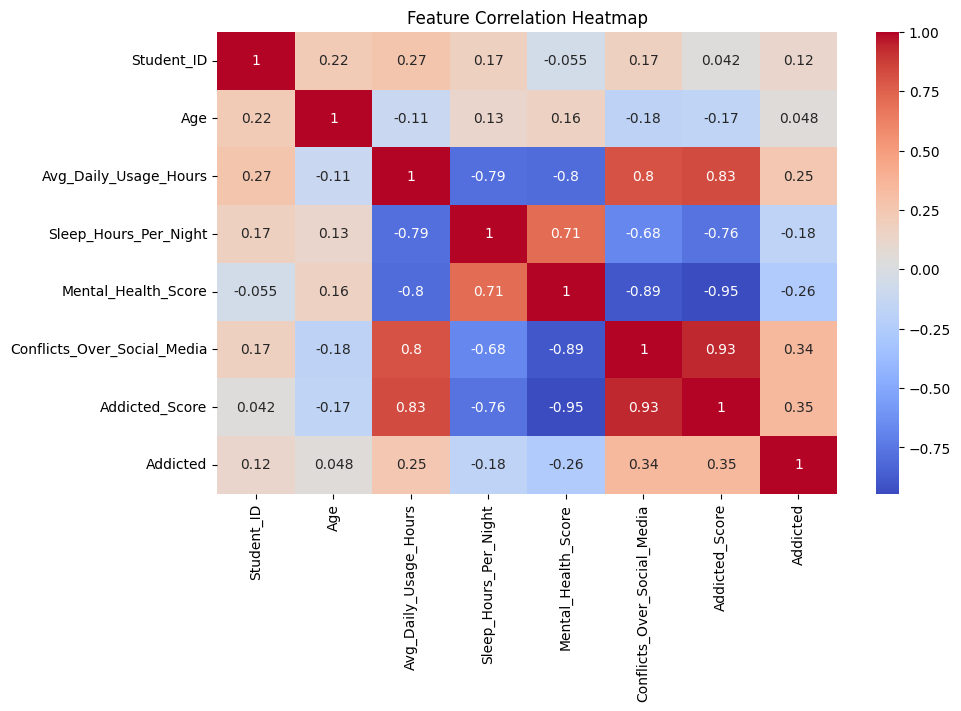

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:

label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])


X = df.drop(["Addicted", "Addiction_Level", "Addicted_Score"], axis=1)
y_binary = df["Addicted"]
y_multi = df["Addiction_Level"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)


print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00       138

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



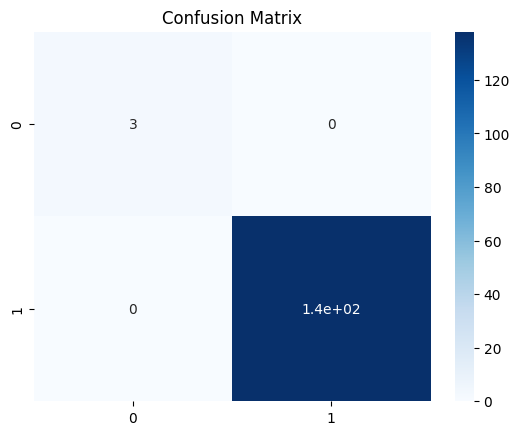

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42
)
rf_multi = RandomForestClassifier(n_estimators=300, random_state=42)
rf_multi.fit(x_train, y_train)
y_pred_multi = rf_multi.predict(x_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred_multi))
print(classification_report(y_test, y_pred_multi))

Accuracy Score:  0.9929078014184397
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        79
           1       1.00      1.00      1.00         3
           2       1.00      0.98      0.99        59

    accuracy                           0.99       141
   macro avg       1.00      0.99      1.00       141
weighted avg       0.99      0.99      0.99       141



In [26]:
import joblib

joblib.dump(X.columns.tolist(), 'features_columns.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(rf_model,'addiction_binary_model.pkl')
joblib.dump(rf_multi,'addiction_level_model.pkl')

['addiction_level_model.pkl']

In [31]:
binary_model = joblib.load('addiction_binary_model.pkl')
level_model = joblib.load('addiction_level_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_columns = joblib.load('features_columns.pkl')

In [28]:
print(X.columns)
print(len(X.columns))

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media'],
      dtype='object')
12


In [35]:
user_input = {
    "Student_ID": int(input("Student ID (e.g., 1001): ")),
    "Age": int(input("Age : ")),
    "Gender": int(input("Gender (0=Female, 1=Male) : ")),
    "Academic_Level": int(input("Academic Level (1=School, 2=Undergraduate, 3=Graduate): ")),
    "Country": int(input("Country (Encoded integer, e.g., 0-102): ")),
    "Avg_Daily_Usage_Hours": float(input("Average Usage: ")),
    "Most_Used_Platform": int(input("Most Used Platform (1=FB, 2=IG, 3=TikTok, 4=YT, 5=Others): ")),
    "Affects_Academic_Performance": int(input("Affects_Academic_Performance (0=No, 1=Yes): ")),
    "Sleep_Hours_Per_Night": float(input("Sleep_Hours_Per_Night : ")),
    "Mental_Health_Score": int(input("Mental_Health_Score: ")),
    "Relationship_Status": int(input("Relationship Status (Encoded integer, e.g., 0-2): ")),
    "Conflicts_Over_Social_Media": int(input("Conflicts Over Social Media (0=No, 1=Yes): "))
}

user_df = pd.DataFrame([user_input])
user_df = user_df[feature_columns]

user_scaled = scaler.transform(user_df)
addicted = binary_model.predict(user_scaled)[0]

print("-" * 30)
print("Addicted: ", "Yes" if addicted == 1 else "No")

Student ID (e.g., 1001): 205
Age : 22
Gender (0=Female, 1=Male) : 0
Academic Level (1=School, 2=Undergraduate, 3=Graduate): 2
Country (Encoded integer, e.g., 0-102): 3100
Average Usage: 6.5
Most Used Platform (1=FB, 2=IG, 3=TikTok, 4=YT, 5=Others): 2
Affects_Academic_Performance (0=No, 1=Yes): 1
Sleep_Hours_Per_Night : 5
Mental_Health_Score: 5
Relationship Status (Encoded integer, e.g., 0-2): 1
Conflicts Over Social Media (0=No, 1=Yes): 0
------------------------------
Addicted:  Yes
